HW2, Problem4 
part a: 

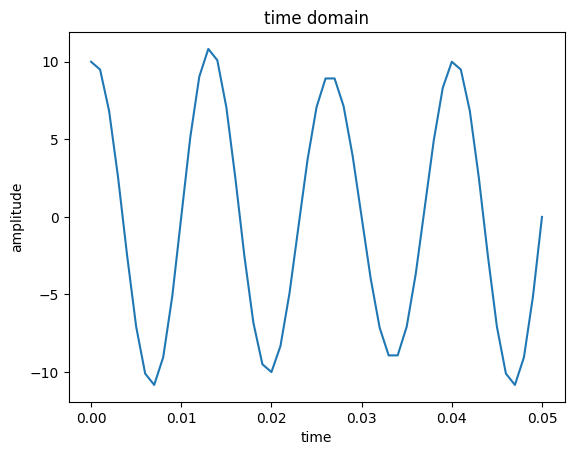

In [57]:
import numpy as np
import matplotlib.pyplot as plt
fs = 1000
T = 10
t = np.arange(0, T, 1/fs)

x1 = 1 * np.sin(2*np.pi*100 *t)
x2 = 10 * np.sin(2*np.pi*75 * t +np.pi/2)
x = x1 + x2

#only keep the ones until 50ms
mask = []
for value in t:
    if value <=0.05:
        mask.append(True)
    else:
        mask.append(False)

plt.figure()
plt.plot(t[mask], x[mask])
plt.xlabel("time")
plt.ylabel("amplitude")
plt.title("time domain")
plt.show()

Explanation for the code: we set up the fs and the time, and based on that we make an array of the time intervals we sample the signal. We write out the two sine waves and add them together. We then make an mask array that is only TRUE for time until 50ms. We then graph it out. 

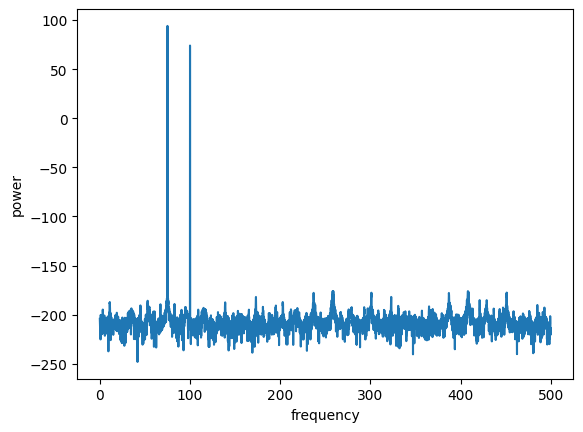

In [58]:
X = np.fft.fft(x) #convert to freq domain
freq = np.fft.fftfreq(fs*T, d=1/fs) #maps index to frequency

power = np.abs(X)**2

#only keep the positive values because the output above was symmetric
positive = []
for value in freq:
    if value >= 0:
        positive.append(True)
    else:
        positive.append(False)
        
freq_pos = freq[positive]
power_pos = power[positive]

# convert power to dB
power_db = 10 * np.log10(power_pos)

plt.figure()
plt.plot(freq_pos, power_db)
plt.xlabel("frequency")
plt.ylabel("power")
plt.show()

Explantation: We convert the time domain signal to frequency domain using fast fourier transform. we calculate the power and only keep the positive values. We convert power to dB and graph it out. 

part b: 

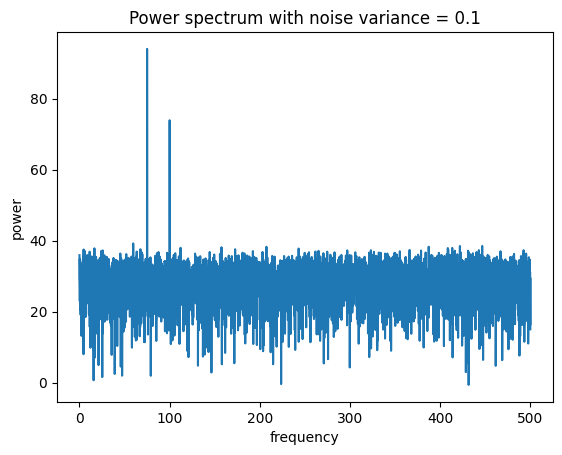

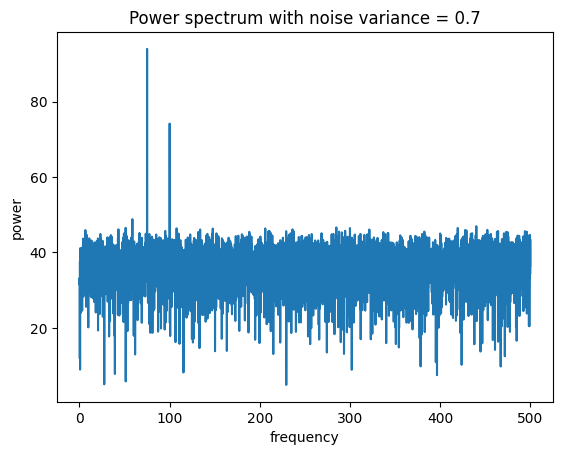

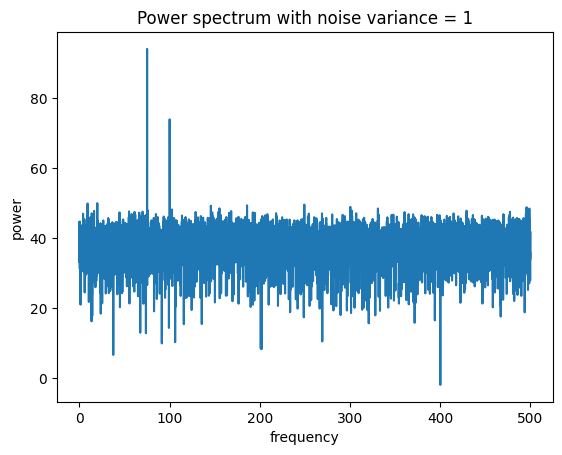

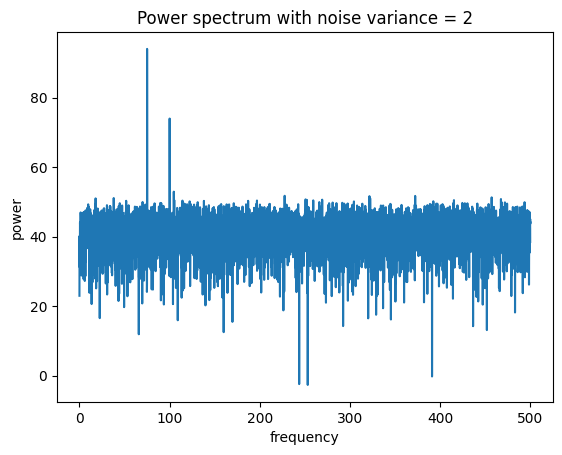

In [59]:
def with_noise(signal, variance):
    std = np.sqrt(variance)
    
    noise = np.random.normal(0, std, size=len(signal))
    
    noisy_signal = signal + noise
    X = np.fft.fft(noisy_signal)
    freq = np.fft.fftfreq(len(noisy_signal), d=1/fs)

    power = np.abs(X)**2

    positive = []
    for value in freq:
        if value >= 0:
            positive.append(True)
        else:
            positive.append(False)
            
    freq_pos = freq[positive]
    power_pos = power[positive]

    power_db = 10 * np.log10(power_pos)

    plt.figure()
    plt.plot(freq_pos, power_db)
    plt.xlabel("frequency")
    plt.ylabel("power")
    plt.title(f"Power spectrum with noise variance = {variance}")
    plt.show()
    
with_noise(x, 0.1)
with_noise(x, 0.7)
with_noise(x, 1)
with_noise(x, 2)
        

Code Explanation:
We convert the variance to standard deviation and use it to generate a noise. We add the noise to the original signals and we repeat the process in part a to output 4 plots of the signal with noise generated with 4 different variances. 

Obeservation report: The plots all shows 2 peaks at 75Hz and 100Hz, which are coming from the initial two sine waves. As the noise variance increases, the overall power across all frequencies increases, raising the noise floor. Because of this, the two peaks became less sharp as the noise's power increases

part c:


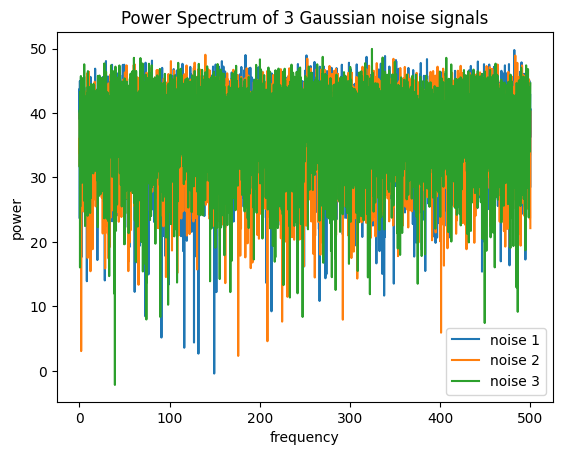

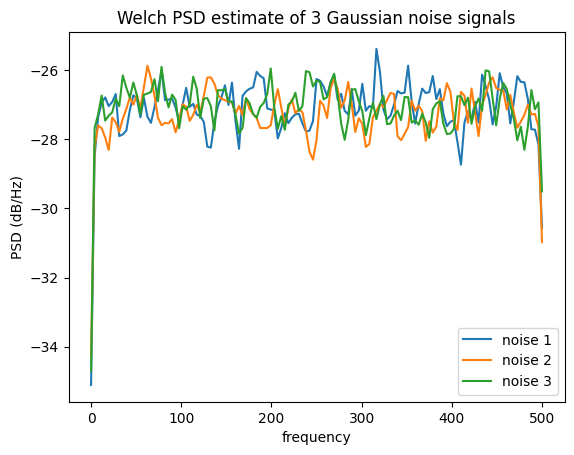

In [60]:
N = fs * T
noise1 = np.random.normal(0,1, size=N)
noise2 = np.random.normal(0,1, size=N)
noise3 = np.random.normal(0,1, size=N)


def get_powerSpectrum(signal):
    N = len(signal)

    X = np.fft.fft(signal)
    freq = np.fft.fftfreq(N, d=1/fs)

    power = np.abs(X)**2

    positive = []
    for value in freq:
        if value >= 0:
            positive.append(True)
        else:
            positive.append(False)
    return freq[positive], power[positive]


f1, p1 = get_powerSpectrum(noise1)
f2, p2 = get_powerSpectrum(noise2)
f3, p3 = get_powerSpectrum(noise3)

plt.figure()
plt.plot(f1, 10*np.log10(p1), label="noise 1")
plt.plot(f2, 10*np.log10(p2), label="noise 2")
plt.plot(f3, 10*np.log10(p3), label="noise 3")
plt.xlabel("frequency")
plt.ylabel("power")
plt.title("Power Spectrum of 3 Gaussian noise signals")
plt.legend()
plt.show()

from scipy.signal import welch
fw1, psd1 = welch(noise1, fs)
fw2, psd2 = welch(noise2, fs)
fw3, psd3 = welch(noise3, fs)

plt.figure()
plt.plot(fw1, 10*np.log10(psd1), label="noise 1")
plt.plot(fw2, 10*np.log10(psd2), label="noise 2")
plt.plot(fw3, 10*np.log10(psd3), label="noise 3")
plt.xlabel("frequency")
plt.ylabel("PSD (dB/Hz)")
plt.title("Welch PSD estimate of 3 Gaussian noise signals")
plt.legend()
plt.show()

Code Explanation:
We generate three Gaussian noise signals with mean 0 and variance 1. We compute their power spectra using FFT, keep only positive frequencies, and plot them in dB. Then, we use Welch’s method to estimate the PSD of each signal, which averages over segments to produce a smoother result, and plot them for comparison.

In the noise plot, everything are very jagged and all 3 lines looks very different. This is expected because the noises are made at random even though they follow a normal distribution. The energy is also pretty uniform across the frequencies. Welch reduces variance by averaging, so in the Wlch PSD graph, the lines looks more similar to each other. The noise signals become less random after averaging. 

Problem 5:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, spectrogram

# ------------------ File Path and Macros ------------------

filename = 'tfo_dataset.csv'  # TODO: Replace with your actual file path
Fs = 8000  # Sampling frequency in Hz
SSD = [1.5, 3, 4.5, 7, 10]  # Source-to-Detector Distances

# ------------------ Load Data ------------------

T = pd.read_csv(filename)
detector_data = T[['ch4Volts']].to_numpy().T

def estimate_carrier_frequencies(signal, Fs):
    """
    TODO: Use FFT to find two dominant carrier frequencies
    Inputs:
        signal - 1D signal from any detector
        Fs - sampling rate in Hz
    Output:
        f1 - estimated carrier frequency 1
        f2 - estimated carrier frequency 2
    """
    x = signal.flatten()
    x = x - np.mean(x)
    
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/Fs)
    power = np.abs(X)**2
    
    valid = []  #ignore  low frequency at 0Hz (DC)
    for value in freqs:
        if value > 5:
            valid.append(True)
        else:
            valid.append(False)

    freqs_valid = freqs[valid]
    power_valid = power[valid]
    first_idx = np.argmax(power_valid)
    f1 = freqs_valid[first_idx]

    #remove frequencies close to first peak
    min_distance_hz = 100
    power_copy = power_valid.copy()
    for i in range(len(freqs_valid)):
        if abs(freqs_valid[i] - f1) < min_distance_hz:
            power_copy[i] = 0

    #find strongest other peak
    second_idx = np.argmax(power_copy)
    f2 = freqs_valid[second_idx]


    return f1, f2

def iq_demodulate(signal, fc, Fs):
    """
    TODO: Perform I/Q demodulation of input signal
    Inputs:
        signal - 1D signal to demodulate
        fc - carrier frequency to demodulate
        Fs - sampling rate
    Output:
        demod - demodulated signal envelope via sqrt(I^2 + Q^2)
    """
    x = signal.flatten()
    t = np.arange(len(x)) / Fs

    I = x*np.cos(2*fc*t*np.pi)
    Q = x*np.sin(2*fc*t*np.pi)
    
    I_LPF = lowpass_filter(I, 15, Fs)
    Q_LPF = lowpass_filter(Q, 15, Fs)
    demod = np.sqrt(I_LPF**2 + Q_LPF**2)
    return demod


def lowpass_filter(data, cutoff, Fs):
    """
    TODO: Apply low-pass filtering for I/Q demodulation
    Inputs:
        data   - 1D signal to demodulate
        cutoff - Cutoff frequency for low-pass in Hz (use 15Hz here)
        Fs     - Sampling rate in Hz
    Output:
        filtered - Filtered version of input
    """
    Wn = cutoff / (Fs / 2)
    b, a = butter(4, Wn, btype='low')
    filtered = filtfilt(b, a, data)

    return filtered

def plot_spectrogram(signal, Fs, window_sec, overlap):
    """
    TODO: Plot spectrogram of input 1D signal
    Requirements:
      - Frequency on x-axis, time on y-axis
      - Spectrum type: 'power'
      - X-axis limit: [0, 5] Hz
    Inputs:
      signal      - A 1D signal
      Fs          - Sampling frequency (e.g., 80 Hz after downsampling)
      window_sec  - Window size in seconds (e.g., 60)
      overlap     - Fractional overlap (e.g., 0.5)
    """
    x = signal.flatten()
    x = x - np.mean(x)

    nperseg = int(window_sec * Fs)
    noverlap = int(overlap * nperseg)
    f, t, Sxx = spectrogram(
        x,
        fs=Fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        mode='psd'
    )
    #convert the power values into dB
    Sxx_dB = 10 * np.log10(Sxx)

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(f, t, Sxx_dB.T, shading='gouraud')
    plt.xlim([0, 5])
    plt.xlabel('Frequency')
    plt.ylabel('Time')
    plt.colorbar(label='Power')
    plt.show()



In [62]:

# ------------------ Estimate Carrier Frequencies ------------------

f1, f2 = estimate_carrier_frequencies(detector_data, Fs)
print(f"Estimated carrier frequencies: f1 = {f1:.2f} Hz, f2 = {f2:.2f} Hz")

Estimated carrier frequencies: f1 = 687.65 Hz, f2 = 925.68 Hz


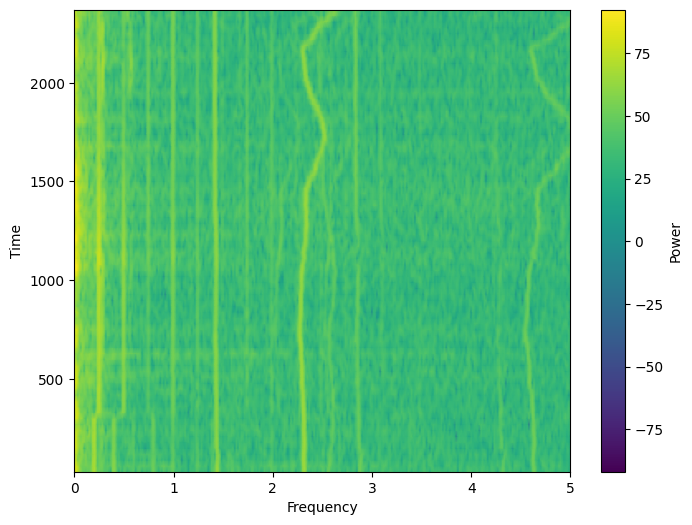

In [63]:
WL1_D4_demod = iq_demodulate(detector_data, f1, Fs)
WL2_D4_demod = iq_demodulate(detector_data, f2, Fs)

WL1_D4_down = WL1_D4_demod[::100]
WL2_D4_down = WL2_D4_demod[::100]

# ------------------ Plot Spectrogram ------------------

plot_spectrogram(WL2_D4_down, Fs / 100, 60, 0.5)

In the spectrogram there are two high power frequencies that varies over time. One is at around 2.3Hz and the other and 4.6Hz. Since this spectrogram only shows low frequency tissue response, those 2 signals are not from the LEDs. The frequencies starts stable then start to varies as time goes on. The second component is approximately twice the first, this might mean that it is a harmonic of the fundamental frequency. Several constant high power signals are near the frequencies close to 0, they might be the result of some DC signals, possibly from the enviroment's noise or light. In the context of maternal status monitoring, The signal at around 1.4 Hz may be the mother's heart rate and the one at 2.3Hz is the fetus's since it is higher. The change in frequency may indicate the fetus experienced some change.

Code Explanation for estimate_carrier_frequencies:

We flatten the signal and remove its average to reduce the DC component. We use FFT to convert the signal to the frequency domain and compute the power spectrum. We find the strongest peak, remove nearby frequencies to avoid picking the same peak twice, and then find the second strongest peak. These two peaks are returned as the carrier frequencies.

iq_demodulate:

We flatten the signal and create a time array. We multiply the signal by cosine and sine waves at the carrier frequency to get the I and Q components, which shift the signal to low frequency. We then apply a low-pass filter with a 15 Hz cutoff and combine the results using 
sqrt(I^2+Q^2) to obtain the demodulated signal.

lowpass_filter:

We normalize the cutoff frequency using the Nyquist frequency Fs/2. Then we create a Butterworth low-pass filter and apply it using filtfilt to remove high-frequency components while preserving the signal shape.

plot_spectrogram:

We flatten the signal and remove its average. We compute the window size and overlap, then use the spectrogram function to analyze how power changes over time and frequency. Then we convert the power to dB and plot the spectrogram with frequency on the x-axis and time on the y-axis.